<a href="https://colab.research.google.com/github/Maricielo-Gomez/Lenguajes-de-programacion/blob/main/ExamenFinal_Analisis_Financiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Examen Final: Dataset de Kaggle + Análisis Financiero en Colab
Este notebook contiene las instrucciones para que desarrollar el examen final.

## ⭐ PASO 1 — Buscar un dataset en Kaggle
1. Entra a https://www.kaggle.com/datasets
2. Busca un dataset financiero (acciones, criptomonedas, oro, petróleo, etc.)
3. Descárgalo a tu computador (formato CSV).

*Solución: El conjunto de datos "Análisis del precio del oro" consideramos que es la mejor opción porque es un activo financiero clave. Además, el archivo gold_prices_clean proporciona series de tiempo amplias y listas para el análisis.*
https://www.kaggle.com/datasets/endersoncastro/gold-price-analysis-with-r-and-tableau

## ⭐ PASO 2 — Subir el dataset a Colab

In [37]:
from google.colab import files
uploaded = files.upload()

Saving gold_prices_clean.csv to gold_prices_clean.csv


In [39]:
import pandas as pd

df = pd.read_csv('gold_prices_clean.csv')
df.head() # Muestra las primeras 5 filas para verificar la carga

,symbol,date,open,high,low,close,volume,adjusted,ret_1,sma_20,sma_50,sma_200,rsi_14,macd,macd_sig,vol_21,dn,mavg,up,pctB
0,GC=F,2010-10-18,1358.000000,1372.599976,1358.000000,1371.199951,46,1371.199951,0.000073,1327.744995,1274.741997,1189.321999,76.387878,2.181183,2.015175,0.007143,NaN,NaN,NaN,NaN
1,GC=F,2010-10-19,1366.800049,1370.500000,1328.500000,1335.099976,301,1335.099976,-0.026327,1330.879993,1277.429998,1190.408999,56.082258,1.933446,1.998829,0.009664,NaN,NaN,NaN,NaN
2,GC=F,2010-10-20,1336.000000,1345.800049,1334.199951,1343.300049,148,1343.300049,0.006142,1333.534998,1280.372000,1191.534999,58.763692,1.766070,1.952277,0.009554,NaN,NaN,NaN,NaN
3,GC=F,2010-10-21,1344.199951,1346.199951,1317.500000,1324.699951,102,1324.699951,-0.013847,1335.054993,1282.915999,1192.478999,51.136874,1.504374,1.862697,0.009826,NaN,NaN,NaN,NaN
4,GC=F,2010-10-22,1326.699951,1328.099976,1319.000000,1324.400024,113,1324.400024,-0.000226,1336.474994,1285.107998,1193.435499,51.021879,1.280430,1.746243,0.009822,NaN,NaN,NaN,NaN


## ⭐ PASO 3 — Limpieza y preparación del dataset


**- Revisa tipo de datos**

In [92]:
print("--- Información General del Dataset ---")
df.info() #Resumen completo del dataframe

#La columna Dtype permite ver los tipos de datos:
#Object: Texto/String
#int64: Entero
#float64: Decimal
#Non-null: Indica cuantos valores no faltan

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
Index: 3734 entries, 19 to 3752
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   symbol              3734 non-null   object        
 1   date                3734 non-null   datetime64[ns]
 2   open                3734 non-null   float64       
 3   high                3734 non-null   float64       
 4   low                 3734 non-null   float64       
 5   close               3734 non-null   float64       
 6   volume              3734 non-null   int64         
 7   adjusted            3734 non-null   float64       
 8   ret_1               3734 non-null   float64       
 9   sma_20              3734 non-null   float64       
 10  sma_50              3734 non-null   float64       
 11  sma_200             3734 non-null   float64       
 12  rsi_14              3734 non-null   float64       
 13  macd        

- Convierte fechas

In [53]:
#Convertir fechas
COLUMNA_FECHA = 'date'
df[COLUMNA_FECHA] = pd.to_datetime(df[COLUMNA_FECHA], errors='coerce')

In [52]:
#Eliminar filas con fechas no válidas
df.dropna(subset=[COLUMNA_FECHA], inplace=True)

**- Ordenar fechas**

In [51]:
df.sort_values(by=COLUMNA_FECHA, inplace=True)
print("Dataset ordenado por fecha y columna 'date' convertida a datetime.")

Dataset ordenado por fecha y columna 'date' convertida a datetime.


**- Manejar valores nulos:**

*Las 19 filas faltantes se encuentran al inicio de la serie (donde los indicadores no pueden calcularse).
La mejor práctica aquí es ELIMINAR esas filas.

In [55]:
#Eliminación de las filas nulas
df.dropna(inplace=True)

In [57]:
print(f"\nNúmero de filas eliminadas por valores nulos: {3753 - df.shape[0]}")


Número de filas eliminadas por valores nulos: 19


In [58]:
print(f"Nuevo tamaño del DataFrame: {df.shape[0]} filas.")

Nuevo tamaño del DataFrame: 3734 filas.


In [61]:
df.info() #Resumen del dataframe organizado

<class 'pandas.core.frame.DataFrame'>
Index: 3734 entries, 19 to 3752
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   symbol    3734 non-null   object        
 1   date      3734 non-null   datetime64[ns]
 2   open      3734 non-null   float64       
 3   high      3734 non-null   float64       
 4   low       3734 non-null   float64       
 5   close     3734 non-null   float64       
 6   volume    3734 non-null   int64         
 7   adjusted  3734 non-null   float64       
 8   ret_1     3734 non-null   float64       
 9   sma_20    3734 non-null   float64       
 10  sma_50    3734 non-null   float64       
 11  sma_200   3734 non-null   float64       
 12  rsi_14    3734 non-null   float64       
 13  macd      3734 non-null   float64       
 14  macd_sig  3734 non-null   float64       
 15  vol_21    3734 non-null   float64       
 16  dn        3734 non-null   float64       
 17  mavg      3734 non

## ⭐ PASO 4 — Análisis financiero básico
Calcula:
- Rendimiento diario
- Rendimiento promedio
- Volatilidad
- Máx y mín históricos

*Para estos cálculos se debe usar la columna con los precios de cierre*

- Rendimiento diario: El rendimiento diario es el cambio porcentual de un día al siguiente.

In [70]:
# Calcular el rendimiento diario y guardarlo en una nueva columna
# El .pct_change() calcula el cambio porcentual entre la fila actual y la anterior.
df['Rendimiento_Diario'] = df['close'].pct_change()

In [71]:
# Muestra las primeras filas con el nuevo cálculo
display(df[['date', 'close', 'Rendimiento_Diario']].head())

,date,close,Rendimiento_Diario
19,2010-11-12,1365.400024,NaN
20,2010-11-15,1368.400024,0.002197
21,2010-11-16,1338.300049,-0.021996
22,2010-11-17,1336.800049,-0.001121
23,2010-11-18,1352.900024,0.012044


- **Rendimiento promedio:** Es la media aritmética de los rendimientos diarios

In [73]:
#Calcular el rendimiento promedio diario
rendimiento_promedio_diario = df['Rendimiento_Diario'].mean()

In [74]:
#Anualizar el rendimiento promedio (multiplicando por el número de días de trading, ~252)
rendimiento_promedio_anualizado = rendimiento_promedio_diario * 252

In [76]:
print("\n--- Rendimiento Promedio ---")
print(f"Rendimiento Promedio Diario: {rendimiento_promedio_diario:.6f}")
print(f"Rendimiento Promedio Anualizado: {rendimiento_promedio_anualizado:.4f} ({rendimiento_promedio_anualizado*100:.2f}%)")


--- Rendimiento Promedio ---
Rendimiento Promedio Diario: 0.000320
Rendimiento Promedio Anualizado: 0.0807 (8.07%)


- **Volatilidad**: Mide el riesgo del rendimiento del activo

In [77]:
#Calcular la volatilidad diaria (Desviación Estándar)
volatilidad_diaria = df['Rendimiento_Diario'].std()

In [80]:
import numpy as np
# Anualizar la volatilidad (multiplicando por la raíz cuadrada del número de días de trading)
volatilidad_anualizada = volatilidad_diaria * np.sqrt(252)

In [82]:
print("\n--- Volatilidad ---")
print(f"Volatilidad Diaria (Riesgo): {volatilidad_diaria:.6f}")
print(f"Volatilidad Anualizada (Riesgo): {volatilidad_anualizada:.4f} ({volatilidad_anualizada*100:.2f}%)")


--- Volatilidad ---
Volatilidad Diaria (Riesgo): 0.010142
Volatilidad Anualizada (Riesgo): 0.1610 (16.10%)


- **Máximos y mínimos históricos:** Estos son los valores más altos y más bajos de la columna de precios de cierre (close) en todo el periodo.

In [83]:
# Calcular el máximo y el mínimo histórico
precio_maximo = df['close'].max()
precio_minimo = df['close'].min()

In [84]:
# Encontrar las fechas en las que ocurrieron
fecha_maximo = df.loc[df['close'].idxmax(), 'date'].strftime('%Y-%m-%d')
fecha_minimo = df.loc[df['close'].idxmin(), 'date'].strftime('%Y-%m-%d')

In [86]:
print("\n--- Máximo y Mínimo Históricos ---")
print(f"Precio Máximo Histórico: {precio_maximo:,.2f} USD (Fecha: {fecha_maximo})")
print(f"Precio Mínimo Histórico: {precio_minimo:,.2f} USD (Fecha: {fecha_minimo})")


--- Máximo y Mínimo Históricos ---
Precio Máximo Histórico: 3,719.40 USD (Fecha: 2025-09-19)
Precio Mínimo Histórico: 1,050.80 USD (Fecha: 2015-12-17)


## ⭐ PASO 5 — Gráficos obligatorios
- Serie de precios
- Rendimientos
- Volumen (si aplica)

In [88]:
import matplotlib.pyplot as plt

**- Serie de precios:** Muestra la tendencia del precio del oro a lo largo del tiempo

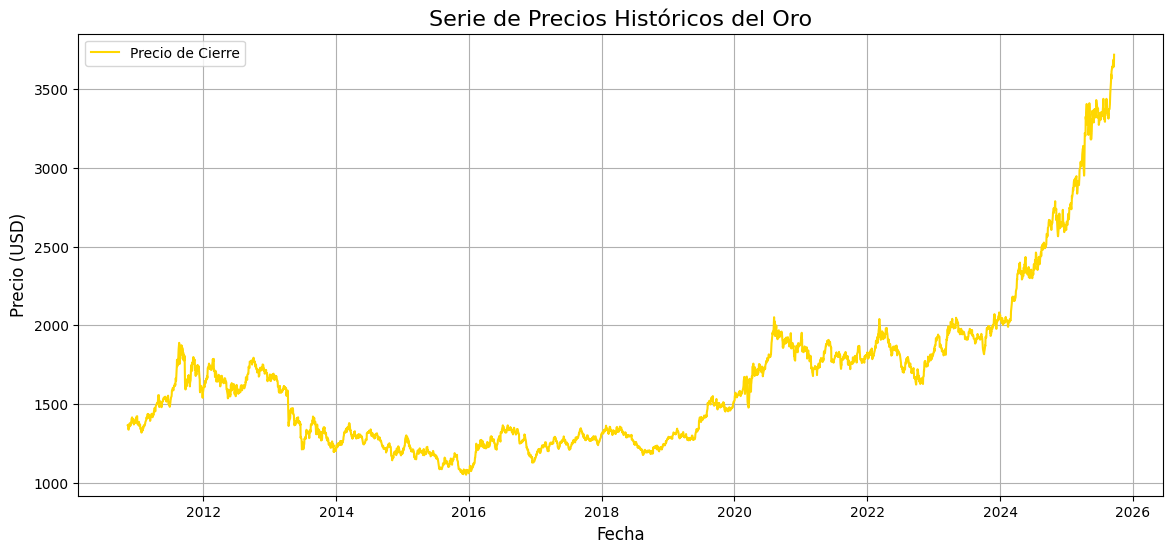

In [89]:
plt.figure(figsize=(14, 6))
# Gráfico principal: Precio de Cierre
plt.plot(df['date'], df['close'], label='Precio de Cierre', color='gold')

plt.title('Serie de Precios Históricos del Oro', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

- **Rendimientos diarios:** Muestra la volatilidad del activo

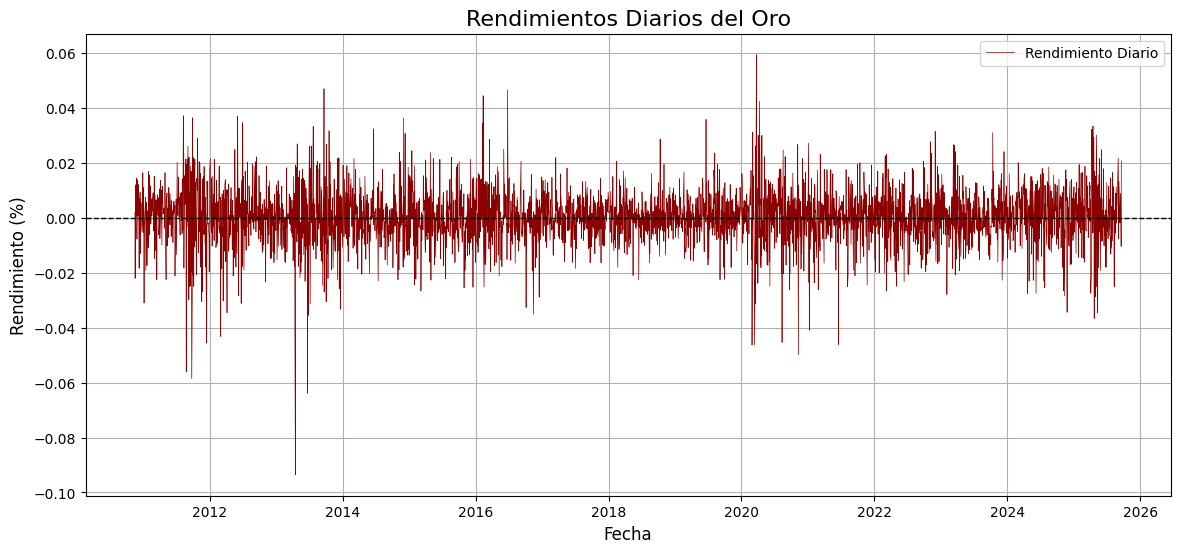

In [90]:
plt.figure(figsize=(14, 6))
# Gráfico de línea para los rendimientos diarios
plt.plot(df['date'], df['Rendimiento_Diario'], label='Rendimiento Diario', color='darkred', linewidth=0.5)

# Línea horizontal en 0 para identificar ganancias (arriba) y pérdidas (abajo)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Rendimientos Diarios del Oro', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

**-Volumen de transacciones:** El volumen ayuda a confirmar la significancia de los movimientos de precios. Un gran cambio de precio con alto volumen es más significativo que un cambio similar con bajo volumen.

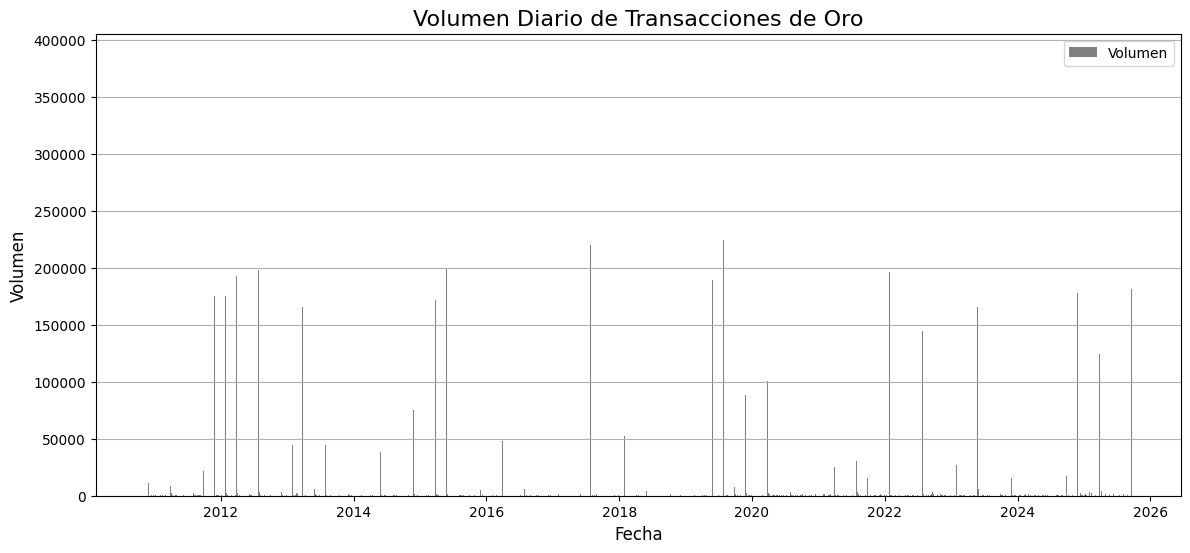

In [91]:
plt.figure(figsize=(14, 6))
# Gráfico de barras para el volumen
plt.bar(df['date'], df['volume'], label='Volumen', color='gray')

plt.title('Volumen Diario de Transacciones de Oro', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Volumen', fontsize=12)
plt.legend()
plt.grid(axis='y') # Mostrar la rejilla solo en el eje Y
plt.show()

## ⭐ PASO 6 — Preguntas de análisis
1. ¿El activo es volátil? ¿Por qué?
2. ¿Tiene tendencia clara?
3. ¿Hay eventos con movimientos fuertes?
4. ¿Es buena inversión a corto/largo plazo?
5. ¿Limitaciones del dataset?

Escribe tus respuestas abajo.

## ⭐ PASO 7 — Conclusiones
Redacta mínimo 5 conclusiones basadas en tu análisis.